# 06 - Integer Programming: the rate schedule

The brief asks for at least one technique beyond RL; this is the Integer Programming
option. It answers a genuinely different question from the MDP: *given expected demand,
what is the best schedule of weekly rates decided in advance?*

## Model

Binary `x[w][k]` selects price level `k` in week `w`; continuous `y[w][k]` is rooms sold.

    maximise    sum_wk (r[w][k] + c*rate[k]) * y[w][k] - sum_wk c*rate[k]*d[w][k]*x[w][k]
    subject to  sum_k x[w][k] = 1                 one rate per week
                y[w][k] <= d[w][k] * x[w][k]      sales bounded by demand, zero if unchosen
                sum_wk y[w][k] <= capacity        inventory
                x binary, y >= 0

The objective is the linear rearrangement of the MDP's reward, so both methods optimise
the same economics. The `y <= d*x` constraints are the standard linearisation that forces
sales to zero at any price level not selected.

**This is not a peer of the MDP policy.** The MILP replaces Poisson arrivals with their
means, so it knows demand exactly, and it commits to the schedule up front, so it cannot
react. It therefore has more information and less flexibility than any policy - its
objective is an optimistic bound, not an attainable target.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plotting import use_style, save_fig, colour
use_style()

import joblib
from config import MULTIPLIERS, HORIZON, RESULTS
from environment import HotelPricingEnv
from lp import solve_lp, capacity_sensitivity, expected_demand_matrix

env = HotelPricingEnv("City Hotel", "May", seed=0)
V_STAR = joblib.load(RESULTS / "vi_solution.joblib")["V_star"]

schedule, objective, _ = solve_lp(env=env)
print(f"MILP objective : {objective:,.0f}")
print(f"exact optimum  : {V_STAR:,.0f}   (from notebook 04)")
print(f"\nschedule: {MULTIPLIERS[schedule]}")

MILP objective : 541,964
exact optimum  : 528,836   (from notebook 04)

schedule: [1.45 1.45 1.45 1.45 1.45 1.45 1.45 1.45 1.45 1.15 1.   0.85]


The MILP objective exceeds the true optimum, exactly as predicted: deterministic demand is
worth more than random demand of the same mean, because there is no risk of ending the
season with unsold rooms.

## 1. The schedule

Rates are held high while inventory is plentiful and cut in the closing weeks - a
mirror image of the pace logic, arrived at without any notion of state.

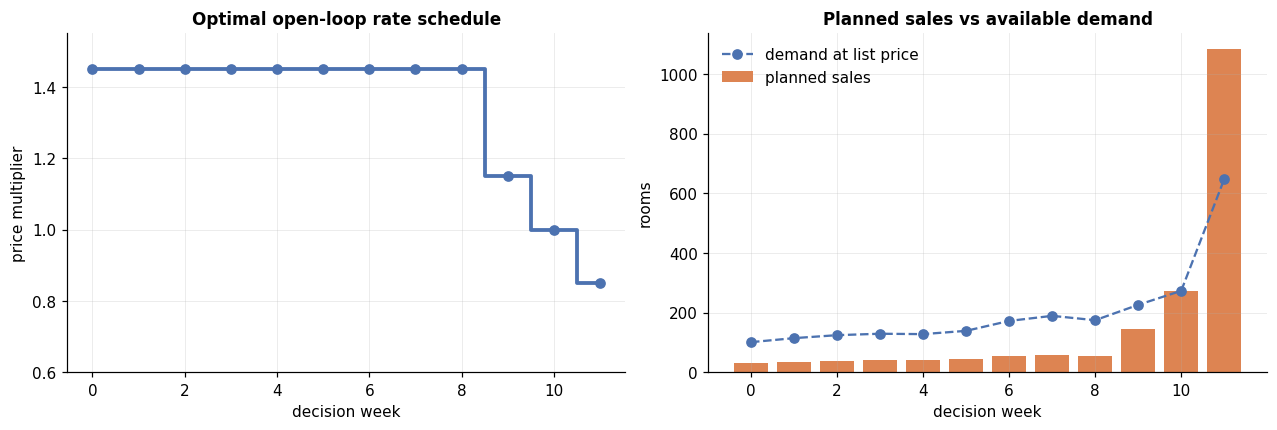

planned total sales 1,892 vs capacity 1,894


In [2]:
demand_matrix = expected_demand_matrix(env)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].step(range(HORIZON), MULTIPLIERS[schedule], where="mid", lw=2.5, color="#4c72b0")
axes[0].scatter(range(HORIZON), MULTIPLIERS[schedule], color="#4c72b0", zorder=3)
axes[0].set(title="Optimal open-loop rate schedule", xlabel="decision week",
            ylabel="price multiplier", ylim=(0.6, 1.55))

chosen = demand_matrix[np.arange(HORIZON), schedule]
axes[1].bar(range(HORIZON), chosen, color="#dd8452", label="planned sales")
axes[1].plot(range(HORIZON), demand_matrix[:, 2], "o--", color="#4c72b0",
             label="demand at list price")
axes[1].set(title="Planned sales vs available demand", xlabel="decision week",
            ylabel="rooms")
axes[1].legend()
save_fig("06_lp_schedule")
plt.show()
print(f"planned total sales {chosen.sum():,.0f} vs capacity {env.capacity:,}")

## 2. Sensitivity: the shadow price of a room

Binary variables mean the LP duals are unavailable directly, so the marginal value of
inventory is obtained numerically by re-solving at scaled capacities. The marginal revenue
per extra room falls as capacity grows - the hotel is forced to discount deeper to fill the
additional rooms, which is the classic diminishing return to capacity.

In [3]:
sensitivity = pd.DataFrame(capacity_sensitivity(env))
sensitivity.round(1)

,factor,capacity,objective,marginal_revenue_per_room
0,0.8,1515,465438.8,NaN
1,0.9,1704,502460.4,195.9
2,1.0,1894,541963.8,207.9
3,1.1,2083,579902.5,200.7
4,1.2,2272,615169.6,186.6


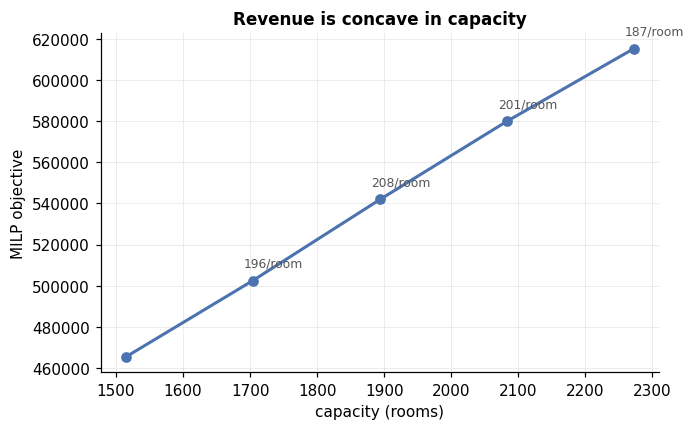

In [4]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(sensitivity["capacity"], sensitivity["objective"], "o-", lw=2, color="#4c72b0")
ax.set(xlabel="capacity (rooms)", ylabel="MILP objective",
       title="Revenue is concave in capacity")
for _, row in sensitivity.iloc[1:].iterrows():
    ax.annotate(f"{row['marginal_revenue_per_room']:.0f}/room",
                (row["capacity"], row["objective"]), textcoords="offset points",
                xytext=(-6, 9), fontsize=8, color="#555")
save_fig("06_capacity_sensitivity")
plt.show()

## 3. Replaying the schedule under real uncertainty

The objective above assumes demand equals its mean. Playing the same schedule in the
stochastic simulator shows what it actually earns - the gap between the two is the cost of
planning against averages, and it is the reason a state-dependent policy is worth having.

In [5]:
from metrics import compare
import policies as P

realised, _ = compare(HotelPricingEnv("City Hotel", "May", seed=0),
                      {"MILP schedule": P.lp_policy(schedule)}, n_episodes=3000, seed=777)
realised_revenue = realised.loc["MILP schedule", "net_revenue"]

print(f"MILP objective (mean demand) : {objective:>10,.0f}")
print(f"realised under uncertainty   : {realised_revenue:>10,.0f}"
      f"   ({100 * (realised_revenue / objective - 1):+.1f}%)")
print(f"exact optimal policy V*      : {V_STAR:>10,.0f}")
print(f"\nthe open-loop schedule captures "
      f"{100 * realised_revenue / V_STAR:.1f}% of what a reactive policy achieves")
realised.round(2)

MILP objective (mean demand) :    541,964
realised under uncertainty   :    510,127   (-5.9%)
exact optimal policy V*      :    528,836

the open-loop schedule captures 96.5% of what a reactive policy achieves


,net_revenue,ci95,gross_revenue,revpar,adr,occupancy,sell_out_rate,turned_away,mean_multiplier
strategy,,,,,,,,,
MILP schedule,510127.33,1428.76,511202.93,89.97,95.74,0.94,0.49,105.45,1.34


In [6]:
np.save(RESULTS / "lp_schedule.npy", schedule)
joblib.dump({"objective": objective, "realised": realised_revenue,
             "sensitivity": sensitivity}, RESULTS / "lp_solution.joblib")
print("saved lp_schedule.npy and lp_solution.joblib")

saved lp_schedule.npy and lp_solution.joblib
